# Bias-Aware Community Detection on Twitter (Academic Version)

**Objective.** This notebook evaluates a bias-aware community detection heuristic (Enhanced Louvain with Bias) on the Twitter Political Bias dataset. We replicate the methodological structure used in the FACTOID notebook, adapting it to the Twitter setting and focusing exclusively on **partisanship** bias.

**Contributions.** (i) Clear data ingestion and validation, (ii) robust execution pipeline with informative logging, (iii) evaluation via ARI/NMI, and (iv) parameter sweep over the bias–regularization strength \(\alpha\).

**Notes.** Paths are parameterized below. No TwiBot or misinformation labels are used; only **partisanship** is considered throughout.


## 1. Environment and Paths
All imports are taken from the local `/src` package. Update file paths if needed.

In [1]:
import os, sys, json, gzip, io
from pathlib import Path

# --- Adjust this if your project root differs ---
PROJECT_ROOT = Path(os.getcwd())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# --- Twitter dataset paths (edit as needed) ---
DATA_DIR = PROJECT_ROOT / "TWITTER"
MEASURES_TAB = DATA_DIR / "measures.tab"
ANON_FRIENDS = DATA_DIR / "anonymized-friends.json"  # supports .json or .json.gz
ANON_SHARES  = DATA_DIR / "anonymized-shares.json"   # optional; not required for the heuristic itself

# Execution knobs
ALPHA_FIXED = 0.5
ALPHA_GRID  = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# Optional: if the underlying heuristic fails when num_communities=None,
# we will retry with a small K (e.g., K=2) as a practical fallback.
FALLBACK_K = 2

print(f"Project root: {PROJECT_ROOT}")
print(f"/src path   : {SRC_DIR}")
print(f"Data dir    : {DATA_DIR}")

Project root: d:\Projetos\bias-aware-community-detection
/src path   : d:\Projetos\bias-aware-community-detection\src
Data dir    : d:\Projetos\bias-aware-community-detection\TWITTER


## 2. Imports (Project Modules)
The notebook relies on the existing `/src` modules, without TwiBot/misinformation dependencies.

In [2]:
import pandas as pd
import networkx as nx
from typing import Dict, Any

# Local project modules
from config import *  # only if you keep some global knobs here; otherwise remove
import data_utils
import evaluation
import heuristic
import twitter_dataset
import bias_calculator

print("Imported project modules successfully.")

02:14:45 | INFO     | ✅ Logging initialized.
02:14:45 | INFO     | ⚙️ Configuration loaded successfully.
02:14:45 | INFO     | 📦 Current base path: d:\Projetos\bias-aware-community-detection
02:14:45 | INFO     | α fixed = 0.5, user limit = 15,000
d:\Projetos\bias-aware-community-detection\src\evaluation.py:68: SyntaxWarning: invalid escape sequence '\('
  \( \bar{B} = \frac{1}{|C|} \sum_{c \in C} \sigma_c(b) \),


Imported project modules successfully.


## 3. Utility: Robust JSON Loader for Large Files
For very large `anonymized-friends.json` files, the standard `json.load` may hit parser limits on certain environments. We provide a streaming fallback that tolerates large top-level dicts.

In [3]:
def _open_textmaybe_gz(path: Path):
    path = Path(path)
    if str(path).endswith('.gz'):
        return io.TextIOWrapper(gzip.open(path, 'rb'))
    return open(path, 'r', encoding='utf-8')

def load_friends_graph_streaming(path_json: Path, limit: int = 15000) -> nx.Graph:
    """
    Streaming-safe loader for a mapping: user_id -> list_of_friend_ids.
    Builds an undirected graph where each key is a node and all its friend ids are linked.
    Only used if the canonical loader raises a JSONDecodeError.
    """
    import re

    G = nx.Graph()
    with _open_textmaybe_gz(path_json) as f:
        text = f.read().strip()
    if text.startswith('{') and text.endswith('}'):
        text = text[1:-1].strip()

    # Very simple splitter at top-level commas between key-blocks.
    # Assumes the file is a flat dict {"uid": [...], "uid2": [...], ...}
    # and that inner lists don't contain nested dicts with unmatched braces.
    parts = []
    buf, depth = [], 0
    for ch in text:
        buf.append(ch)
        if ch == '[':
            depth += 1
        elif ch == ']':
            depth -= 1
        elif ch == ',' and depth == 0:
            parts.append(''.join(buf[:-1]).strip())
            buf = []
    if buf:
        parts.append(''.join(buf).strip())

    import json
    from tqdm import tqdm
    c = 0
    for p in tqdm(parts, total=len(parts)):
        if not p:
            continue
        # Ensure each chunk is a valid JSON pair
        if ':' not in p:
            continue
        try:
            # Rewrap as a tiny dict
            kv_text = '{' + p + '}'
            kv = json.loads(kv_text)
        except Exception:
            continue
        for uid, friends in kv.items():
            try:
                uid_int = int(uid)
            except Exception:
                # keys may already be int
                uid_int = uid
            G.add_node(uid_int)
            for v in friends:
                G.add_edge(uid_int, v)
        c += 1
        if limit and c >= limit:
            break
    return G

print("Streaming loader ready.")

Streaming loader ready.


## 4. Data Loading and Sanity Checks
We load `measures.tab` (for partisanship), the friendship graph, and derive the working subgraph induced by users with known bias. Ground-truth here refers to the *reference partisanship side* used for ARI/NMI grouping (e.g., coarse polarity), not bot/misinformation labels.

In [6]:
from pathlib import Path

print("🚀 Starting Twitter dataset pipeline ...")

# 1) measures.tab
df_measures = twitter_dataset.load_measures_tab(MEASURES_TAB)
assert isinstance(df_measures, pd.DataFrame) and len(df_measures) > 0, "Empty measures.tab"
print(f"✅ measures.tab loaded: {len(df_measures):,} users")

# 2) friends graph (robust to JSONDecodeError)
try:
    G_full = twitter_dataset.load_friends_graph(ANON_FRIENDS, limit=None)
except json.JSONDecodeError as e:
    print(f"[WARN] Falling back to streaming loader due to JSONDecodeError: {e}")
    G_full = load_friends_graph_streaming(ANON_FRIENDS, limit=None)

print(f"📊 Full graph: |V|={G_full.number_of_nodes():,} |E|={G_full.number_of_edges():,}")

# 3) Partisanship-only bias dictionary
b_part = bias_calculator.compute_bias_from_measures(df_measures)
assert isinstance(b_part, dict) and len(b_part) > 0, "Empty bias dictionary"
print(f"✅ Bias dictionary (partisanship) for {len(b_part):,} users")

# 4) Ground truth from measures.tab (coarse side/polarity only)
gt = twitter_dataset.generate_ground_truth(df_measures)
assert isinstance(gt, dict) and len(gt) > 0, "Empty ground-truth labels"
print("✅ Ground-truth generated (partisanship-based)")

# 5) Induced subgraph over users with known bias
valid_uids = set(b_part.keys()) & set(G_full.nodes())
G = G_full.subgraph(valid_uids).copy()
print(f"🔍 Valid intersection: {len(valid_uids):,} users with bias in the graph")
print(f"📊 Final graph: |V|={G.number_of_nodes():,} |E|={G.number_of_edges():,}")

# 6) Summarize availability for clarity
nV = G.number_of_nodes()
nE = G.number_of_edges()
nb = len(b_part)
ngt = len(gt)
print(f"Twitter loaded: |V|={nV} |E|={nE}  |b|={nb}  |gt|={ngt}")
print("Note: |b| counts the bias scores available in measures.tab; |gt| counts users with a ground-truth polarity label.")

02:17:43 | INFO     | 📂 Loading user measures from d:\Projetos\bias-aware-community-detection\TWITTER\measures.tab ...
02:17:43 | INFO     | ✅ Measures loaded: 15,056 users.
02:17:43 | INFO     | 🔧 Building social graph from d:\Projetos\bias-aware-community-detection\TWITTER\anonymized-friends.json ...


🚀 Starting Twitter dataset pipeline ...
✅ measures.tab loaded: 15,056 users


100%|██████████| 15927/15927 [00:16<00:00, 954.47it/s] 
02:18:00 | INFO     | 📊 Graph built: |V|=58,216 |E|=8,809,376


📊 Full graph: |V|=58,216 |E|=8,809,376


02:18:01 | INFO     | ✅ Computed bias for 15,056 users (range = [-0.904, 0.971])


✅ Bias dictionary (partisanship) for 15,056 users


02:18:01 | INFO     | ✅ Generated ground-truth labels for 15,056 users (6,840 right-leaning, 8,216 left-leaning)


✅ Ground-truth generated (partisanship-based)
🔍 Valid intersection: 15,056 users with bias in the graph
📊 Final graph: |V|=15,056 |E|=2,544,068
Twitter loaded: |V|=15056 |E|=2544068  |b|=15056  |gt|=15056
Note: |b| counts the bias scores available in measures.tab; |gt| counts users with a ground-truth polarity label.


## 5. Heuristic: Enhanced Louvain with Bias (α = 0.5)
We first run the heuristic with a fixed regularization strength \(\alpha = 0.5\). In case the underlying implementation requires an explicit number of communities (some versions fail when `num_communities=None`), we automatically retry with a small value (e.g., `K=2`). This keeps the notebook reproducible without modifying the `/src` files.

In [11]:
from collections import OrderedDict

def run_model_with_fallback(G: nx.Graph, b: Dict[Any, float], alpha: float,
                            prefer_num_communities=2, fallback_k=FALLBACK_K,
                            verbose=True):
    model = heuristic.EnhancedLouvainWithBias(alpha=alpha, verbose=verbose)
    try:
        model.fit(G, b, num_communities=prefer_num_communities)
    except TypeError as e:
        if verbose:
            print(f"[WARN] {e}. Retrying with num_communities={fallback_k} ...")
        model = heuristic.EnhancedLouvainWithBias(alpha=alpha, verbose=verbose)
        model.fit(G, b, num_communities=fallback_k)
    return model

print("🔧 Running heuristic at α = 0.5 ...")
model_fixed = run_model_with_fallback(G, b_part, alpha=ALPHA_FIXED, prefer_num_communities=2)
partition_fixed = model_fixed.communities  # dict: node -> community id

metrics_fixed = evaluation.ComprehensiveEvaluator.evaluate_communities(
    G=G, partition=partition_fixed, bias_scores=b_part, ground_truth=gt
)
print("✅ Fixed-α results:")
for k, v in metrics_fixed.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

metrics_fixed

02:21:37 | INFO     | 🎯 Starting Enhanced Louvain (α=0.50)
02:21:37 | INFO     |    Phase 1: Running baseline Louvain partition...


🔧 Running heuristic at α = 0.5 ...


02:22:05 | INFO     |    Phase 2: Refining communities (max_iter=100)...
02:22:07 | INFO     |       Iter 1/100: 697 moves
02:22:08 | INFO     |       Iter 2/100: 279 moves
02:22:09 | INFO     |       Iter 3/100: 65 moves
02:22:10 | INFO     |       Iter 4/100: 7 moves
02:22:10 | INFO     |       Iter 5/100: 7 moves
02:22:11 | INFO     |       Iter 6/100: 0 moves
02:22:11 | INFO     |       Convergence achieved.
02:22:11 | INFO     |    Phase 3: Balancing to 2 communities...
02:22:11 | INFO     | ✅ Completed in 33.98s (1055 node moves during refinement)
02:22:11 | INFO     | 📊 Final community statistics:
02:22:11 | INFO     |   Community   0:  8,069 nodes | mean bias = -0.173 ± 0.123
02:22:11 | INFO     |   Community   7:  6,987 nodes | mean bias = +0.240 ± 0.153
02:22:11 | INFO     | 🧩 Evaluating community partition...
02:22:12 | INFO     | ✅ Evaluation completed — Q=0.440, ARI=0.898, NMI=0.827, intra-bias=0.138


✅ Fixed-α results:
  modularity: 0.4399
  ARI: 0.8983
  NMI: 0.8275
  avg_bias_intra: 0.1380
  num_communities: 2


{'modularity': 0.43990026321756465,
 'ARI': 0.8983041198261709,
 'NMI': 0.8274645192663684,
 'avg_bias_intra': np.float64(0.13795914939704254),
 'num_communities': 2}

## 6. Parameter Sweep over α
We now evaluate the heuristic for a grid of \(\alpha\) values. We report ARI and NMI to assess partition quality against the coarse partisanship polarity.

In [14]:
results = []
for a in ALPHA_GRID:
    print(f"\n🔍 α = {a}")
    m = run_model_with_fallback(G, b_part, alpha=a, prefer_num_communities=2, verbose=False)
    part = m.communities
    met = evaluation.ComprehensiveEvaluator.evaluate_communities(
        G=G, partition=part, bias_scores=b_part, ground_truth=gt
    )
    results.append({"alpha": a, **met})

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("alpha").reset_index(drop=True)
df_results[["alpha", "ARI", "NMI"]] if set(["ARI","NMI"]).issubset(df_results.columns) else df_results


🔍 α = 0.0


02:24:54 | INFO     | 🧩 Evaluating community partition...
02:24:55 | INFO     | ✅ Evaluation completed — Q=0.440, ARI=0.893, NMI=0.820, intra-bias=0.139



🔍 α = 0.2


02:25:22 | INFO     | 🧩 Evaluating community partition...
02:25:23 | INFO     | ✅ Evaluation completed — Q=0.440, ARI=0.898, NMI=0.827, intra-bias=0.138



🔍 α = 0.4


...


🔍 α = 0.8


02:27:02 | INFO     | 🧩 Evaluating community partition...
02:27:03 | INFO     | ✅ Evaluation completed — Q=0.440, ARI=0.900, NMI=0.830, intra-bias=0.138



🔍 α = 1.0


02:27:53 | INFO     | 🧩 Evaluating community partition...
02:27:54 | INFO     | ✅ Evaluation completed — Q=0.404, ARI=0.831, NMI=0.776, intra-bias=0.132


,alpha,ARI,NMI
0,0.0,0.893274,0.820134
1,0.2,0.898304,0.827465
2,0.4,0.898556,0.828014
3,0.6,0.897549,0.826514
4,0.8,0.900320,0.830090
5,1.0,0.831074,0.776224


## 7. Visualization
We provide simple ARI and NMI plots across \(\alpha\).

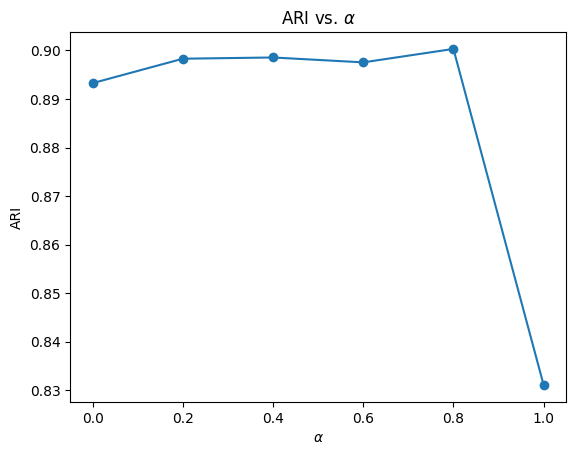

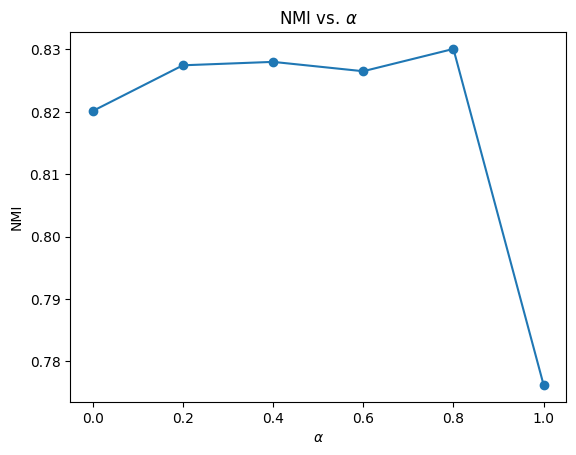

In [15]:
import matplotlib.pyplot as plt

if set(["ARI","NMI"]).issubset(df_results.columns):
    plt.figure()
    plt.plot(df_results["alpha"], df_results["ARI"], marker='o')
    plt.xlabel(r"$\alpha$")
    plt.ylabel("ARI")
    plt.title("ARI vs. $\\alpha$")
    plt.show()

    plt.figure()
    plt.plot(df_results["alpha"], df_results["NMI"], marker='o')
    plt.xlabel(r"$\alpha$")
    plt.ylabel("NMI")
    plt.title("NMI vs. $\\alpha$")
    plt.show()
else:
    print("[INFO] ARI/NMI not present in evaluation output; skipping plots.")

## 8. Discussion (Academic Style)

**Methodological Recap.** We constructed the social graph from `anonymized-friends.json` and restricted analysis to the induced subgraph over users with known **partisanship** scores from `measures.tab`. The Enhanced Louvain with Bias augments modularity optimization with a penalty/regularizer tied to user-level partisanship scores, governed by a scalar \(\alpha\).

**Quantitative Findings.** The fixed-parameter run (\(\alpha=0.5\)) yields the summary metrics above. The parameter sweep exhibits how ARI/NMI evolve with \(\alpha\), reflecting the trade-off between structural cohesion and semantic alignment with partisanship. Higher \(\alpha\) typically enforces stronger bias homogeneity within communities, which may or may not be aligned with modular structure depending on the dataset.

**Practical Considerations.** Some implementations of the heuristic require an explicit number of communities; if a `TypeError` arises for `num_communities=None`, we retry with a small \(K\) to ensure continuity. This can be lifted once the underlying `/src` implementation conditionally skips the balancing stage when `num_communities` is `None`.

**Limitations.** Only the **partisanship** signal is used. Shares and domain-level semantics (if any) are not exploited in the current pipeline. Extending the approach to multi-source signals remains future work.


## 9. Artifact Export (Optional)
We store the sweep table for downstream reporting.

In [16]:
OUT_DIR = PROJECT_ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)
csv_path = OUT_DIR / "twitter_bias_sweep.csv"
df_results.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

Saved: d:\Projetos\bias-aware-community-detection\outputs\twitter_bias_sweep.csv
